***Importación de librerías***

Se importan las librerías que se utilizarán en el proyecto. Estas herramientas permiten trabajar con datos, construir y entrenar la red neuronal en PyTorch, preparar el conjunto de datos y visualizar los resultados obtenidos durante el entrenamiento.

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import TensorDataset, DataLoader

Configuración de la semilla para reproducibilidad


Los modelos de inteligencia artificial usan el azar para algunas cosas, como el orden de los datos o los valores iniciales. Si no controlas estos, cada vez que se ejecute el programa se tendran resultados distintos.

Para solucionar esto, se fija un número "mágico" (la semilla, que en este caso es 42) en todas las herramientas del programa (random, NumPy, PyTorch y la GPU). Así, el "azar" siempre se comporta exactamente de la misma manera, garantizando que cualquiera que corra el código obtenga siempre los mismos resultados.

In [5]:
import random
import numpy as np
import torch

# ==========================================
# 1. DEFINICIÓN DE LA SEMILLA
# ==========================================
# Asigna el valor inicial (42) para los generadores pseudoaleatorios.
seed = 42


# ==========================================
# 2. CONFIGURACIÓN EN LA LIBRERÍA ESTÁNDAR DE PYTHON
# ==========================================
# Controla funciones como random.shuffle() o random.choice().
random.seed(seed)


# ==========================================
# 3. CONFIGURACIÓN EN NUMPY
# ==========================================
# Controla la aleatoriedad en transformaciones de arreglos y matrices con np.random.
np.random.seed(seed)


# ==========================================
# 4. CONFIGURACIÓN EN PYTORCH (CPU)
# ==========================================
# Fija la inicialización de pesos, capas como Dropout y el orden del DataLoader en CPU.
torch.manual_seed(seed)


# ==========================================
# 5. CONFIGURACIÓN EN PYTORCH (GPU / CUDA)
# ==========================================
# Si hay una tarjeta gráfica disponible, fija la aleatoriedad de los cálculos acelerados en la GPU.
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    # torch.cuda.manual_seed_all(seed)  # Descomentar si usas múltiples GPUs


# ==========================================
# EXTRA: REPRODUCIBILIDAD ESTRICTA (OPCIONAL)
# ==========================================
# Fuerza a cuDNN a usar algoritmos deterministas (evita diferencias por cálculo en paralelo).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Detección automática del dispositivo de procesamiento

En este paso detecta automáticamente el mejor procesador disponible en tu equipo para entrenar la red neuronal. Si se tiene una GPU de NVIDIA (CUDA) o un chip de Apple (MPS), lo usará para que el entrenamiento sea muchísimo más rápido. Si no, usará el procesador normal (CPU). Esto hace que el mismo código funcione en cualquier computadora sin tener que cambiar nada.

In [6]:
import torch

# ==========================================
# 1. VERIFICACIÓN DE ACELERACIÓN NVIDIA (CUDA)
# ==========================================
# Revisa si el equipo tiene una GPU de NVIDIA compatible y con controladores CUDA instalados.
# Es la opción ideal para entrenar modelos grandes rápidamente.

# ==========================================
# 2. VERIFICACIÓN DE ACELERACIÓN APPLE (MPS)
# ==========================================
# Revisa si el equipo es una Mac con procesadores Apple Silicon (chips M1, M2, M3, etc.).
# Utiliza Metal Performance Shaders (MPS) para acelerar los cálculos.

# ==========================================
# 3. PROCESADOR PRINCIPAL (CPU)
# ==========================================
# Si no hay ninguna GPU acelerada disponible, usa el procesador tradicional (CPU) como alternativa.

# ==========================================
# SELECCIÓN Y ASIGNACIÓN DINÁMICA DEL DISPOSITIVO
# ==========================================
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

# ==========================================
# CONFIRMACIÓN DEL DISPOSITIVO SELECCIONADO
# ==========================================
# Muestra en pantalla qué dispositivo se terminó asignando ('cuda', 'mps' o 'cpu').
print(f"Dispositivo seleccionado: {device}")

Dispositivo seleccionado: cpu


Carga de Dataset

Cargamos el famoso conjunto de datos Iris, que es como el "Hola Mundo" del aprendizaje automático. Es una tabla de datos muy simple con medidas de flores (como el largo y ancho de sus pétalos y sépalos).

El objetivo es que la IA aprenda a mirar esas medidas y adivinar a qué especie de flor pertenece cada una.

In [7]:
from sklearn.datasets import load_iris

# ==========================================
# 1. CARGA DEL DATASET IRIS
# ==========================================
# Descarga/carga la estructura completa del dataset desde scikit-learn.
# Incluye los datos, las etiquetas, los nombres de las flores y las medidas.
iris = load_iris()


# ==========================================
# 2. EXTRACCIÓN DE LAS CARACTERÍSTICAS (FEATURES)
# ==========================================
# 'iris.data' contiene la matriz con las mediciones numéricas.
# Son 4 columnas: largo y ancho del sépalo, largo y ancho del pétalo.
# Se asignan a 'X' (en mayúscula por convención al ser una matriz).
X = iris.data


# ==========================================
# 3. EXTRACCIÓN DE LAS ETIQUETAS (TARGET/OBJETIVO)
# ==========================================
# 'iris.target' contiene la respuesta correcta para cada flor.
# Son números enteros (0, 1 o 2) que representan la especie de la flor:
# 0 = Setosa, 1 = Versicolor, 2 = Virginica.
# Se asignan a 'y' (en minúscula por convención al ser un vector).
y = iris.target

Normalizar



Ahora se ajustaran todas las medidas de las flores para que estén en la misma escala (mismo rango de números). Como unas medidas pueden ser muy grandes y otras muy pequeñas, si no las escalamos, el modelo podría darle más importancia a una variable solo por tener números más altos. Con StandardScaler, dejamos todas las características centradas en 0 y con la misma importancia, haciendo que el modelo aprenda mucho mejor y más rápido.

In [8]:
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. CREACIÓN DEL ESCALADOR (STANDARDIZER)
# ==========================================
# Instancia la herramienta 'StandardScaler'.
# Este objeto transformará los datos para que tengan una media = 0 y desviación estándar = 1
# (técnicamente conocido como puntuación Z o Z-score).
scaler = StandardScaler()


# ==========================================
# 2. CÁLCULO Y TRANSFORMACIÓN DE LOS DATOS (FIT_TRANSFORM)
# ==========================================
# 'fit_transform' realiza dos acciones en un solo paso sobre la matriz X:
#   1. 'fit': Calcula la media y la desviación estándar de cada columna.
#   2. 'transform': Aplica la fórmula (x - media) / desviación_estandar a cada dato.
#
# Sobrescribimos 'X' con los nuevos valores escalados para que todas las variables
# compitan en igualdad de condiciones durante el entrenamiento.
X = scaler.fit_transform(X)

División del conjunto de datos en entrenamiento y validación

En este paso se divide el conjunto de datos en dos partes: una para entrenar el modelo y otra para validar su desempeño. De esta manera, el modelo aprende utilizando el 80% de los datos y luego se evalúa con el 20% restante, que no vio durante el entrenamiento. Esto permite comprobar qué tan bien generaliza el modelo y detectar posibles problemas de sobreajuste (overfitting).

In [9]:
# ==========================
# 1. DIVIDIR EL DATASET
# ==========================

X_train, X_val, y_train, y_val = train_test_split(
    X,                  # Variables de entrada
    y,                  # Variable objetivo
    test_size=0.2,      # 20% para validación
    random_state=42     # Semilla para obtener siempre la misma división
)

Conversión de los datos a tensores

Convertimos los datos (que hasta ahora eran arreglos normales de NumPy) en Tensores de PyTorch, que es el formato especial de datos que entiende la librería. Además, le asignamos el tipo de número correcto a cada uno: números con decimales (float32) para las medidas de las flores y números enteros (long) para las etiquetas de las clases.

In [10]:
import torch

# ==========================================
# 1. CONVERSIÓN DE CARACTERÍSTICAS A TENSORES (ENTRENAMIENTO)
# ==========================================
# Transforma las entradas de entrenamiento (X_train) en tensores de tipo flotante (float32).
# PyTorch requiere que los datos numéricos de entrada tengan decimales de 32 bits para calcular las operaciones matemáticas y gradientes.
X_train = torch.tensor(X_train, dtype=torch.float32)


# ==========================================
# 2. CONVERSIÓN DE CARACTERÍSTICAS A TENSORES (VALIDACIÓN)
# ==========================================
# Transforma las entradas de validación (X_val) en el mismo formato flotante (float32).
# Esto asegura consistencia de tipos durante la evaluación del modelo.
X_val = torch.tensor(X_val, dtype=torch.float32)


# ==========================================
# 3. CONVERSIÓN DE ETIQUETAS A TENSORES (ENTRENAMIENTO)
# ==========================================
# Transforma las respuestas esperadas (y_train) en tensores de enteros de 64 bits (long).
# Es obligatorio usar números enteros sin decimales porque las funciones de pérdida para clasificación (como CrossEntropyLoss) trabajan con índices de clases (0, 1 o 2).
y_train = torch.tensor(y_train, dtype=torch.long)


# ==========================================
# 4. CONVERSIÓN DE ETIQUETAS A TENSORES (VALIDACIÓN)
# ==========================================
# Transforma las respuestas de validación (y_val) al mismo tipo entero (long) para comparar contra las predicciones del modelo.
y_val = torch.tensor(y_val, dtype=torch.long)

Preparación de Dataset y DataLoaders

Aquí empaquetamos y organizamos nuestros datos para dárselos de comer al modelo. Primero unimos las características con sus etiquetas (TensorDataset), y luego creamos los "cargadores" (DataLoader). En lugar de pasarle todas las flores juntas a la red neuronal, estos cargadores se las van a ir entregando en pequeños lotes (grupos de 16) e irán mezclando los datos de entrenamiento al azar para que el modelo no aprenda memoria ni patrones por orden.

In [11]:
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# 1. EMPAQUETADO DE DATOS (TensorDataset)
# ==========================================
# Une cada conjunto de características (X) con su respectiva etiqueta (y) en un solo objeto.
# Funciona como un catálogo donde cada fila tiene la entrada y la respuesta correcta juntos.

# Empaqueta el conjunto de entrenamiento
train_dataset = TensorDataset(X_train, y_train)

# Empaqueta el conjunto de validación
val_dataset = TensorDataset(X_val, y_val)


# ==========================================
# 2. CREACIÓN DEL CARGADOR DE ENTRENAMIENTO (train_loader)
# ==========================================
# Agrupa los datos en lotes pequeños (batches) e iterables para el modelo.
train_loader = DataLoader(
    train_dataset,
    batch_size=16,  # Entregará las flores de 16 en 16.
    shuffle=True    # Mezcla el orden de los datos en cada época para evitar que el modelo aprenda sesgos.
)


# ==========================================
# 3. CREACIÓN DEL CARGADOR DE VALIDACIÓN (val_loader)
# ==========================================
# Agrupa los datos de evaluación de la misma manera para medir el rendimiento.
val_loader = DataLoader(
    val_dataset,
    batch_size=16   # Usa el mismo tamaño de lote de 16 datos. No requiere shuffle=True porque el orden no altera la evaluación.
)

Definición de la arquitectura del modelo

Ahora creamos una estructura llamada Perceptrón Multicapa (MLP) que procesa la información paso a paso (el cerebro del modelo): recibe las 4 medidas de la flor, las pasa por dos capas intermedias con neuronas que aprenden patrones complejos (gracias a la activación ReLU), y finalmente nos entrega 3 valores a la salida, uno por cada posible especie de Iris.

In [12]:
import torch.nn as nn

# ==========================================
# DEFINICIÓN DE LA CLASE DEL MODELO (nn.Module)
# ==========================================
# Heredamos de 'nn.Module', la clase base obligatoria en PyTorch para crear cualquier red neuronal.
class MLP(nn.Module):

    # ==========================================
    # 1. CONSTRUCTOR Y ARQUITECTURA DE LA RED (__init__)
    # ==========================================
    def __init__(self):
        super().__init__()

        # 'nn.Sequential' empaqueta las capas para que los datos fluyan en secuencia, en orden de arriba a abajo.
        self.network = nn.Sequential(

            # --- CAPA DE ENTRADA Y PRIMERA CAPA OCULTA ---
            # Recibe las 4 características de la flor (largo/ancho de sépalo y pétalo) y las conecta a 16 neuronas.
            nn.Linear(4, 16),

            # Función de activación ReLU: Convierte los valores negativos en 0.
            # Permite que la red aprenda relaciones complejas y no solo líneas rectas.
            nn.ReLU(),

            # --- SEGUNDA CAPA OCULTA ---
            # Comprime la información pasando de las 16 neuronas anteriores a 8 neuronas.
            nn.Linear(16, 8),

            # Función de activación ReLU nuevamente para mantener la no-linealidad.
            nn.ReLU(),

            # --- CAPA DE SALIDA ---
            # Reduce las 8 neuronas a 3 salidas finales (Logits).
            # Cada salida representa la puntuación asignada a una de las 3 especies (Setosa, Versicolor, Virginica).
            nn.Linear(8, 3)
        )

    # ==========================================
    # 2. PROPAGACIÓN HACIA ADELANTE (forward)
    # ==========================================
    # Define la ruta exacta que siguen los datos cuando entran al modelo.
    # PyTorch llama a este método automáticamente cuando ejecutamos 'modelo(x)'.
    def forward(self, x):
        # Pasa los datos de entrada 'x' a través de toda la secuencia definida en 'self.network'
        return self.network(x)

Inicialización del modelo

Aquí le damos "vida" a la red neuronal que diseñamos en el paso anterior y la enviamos a la memoria del procesador que elegimos (sea la GPU o la CPU). Es un paso fundamental: si los datos están en la GPU y el modelo en la CPU (o viceversa), el programa fallará. Con esto nos aseguramos de que todo el entrenamiento se procese en la misma "máquina".

In [13]:
# ==========================================
# 1. CREACIÓN DE LA INSTANCIA DEL MODELO
# ==========================================
# Creamos un objeto concreto a partir de la clase 'MLP' que definimos antes.
# En este momento, PyTorch inicializa los pesos y sesgos de la red neuronal de forma aleatoria.
model = MLP()


# ==========================================
# 2. ENVIAR EL MODELO AL DISPOSITIVO (CPU/GPU)
# ==========================================
# 'model.to(device)' mueve todas las capas, parámetros y tensores internos del modelo
# a la memoria de la aceleradora elegida ('cuda', 'mps' o 'cpu').
# De esta forma, las futuras operaciones se realizarán directamente en ese hardware.
model = model.to(device)

Definición de la función de pérdida y del optimizador

Configuramos a los dos "profesores" del modelo. La función de pérdida (CrossEntropyLoss) actúa como el evaluador: calcula la nota del examen comparando lo que predijo la red contra la respuesta real. El optimizador (Adam) actúa como el tutor: toma esa nota y ajusta los pesos de la red neuronal poco a poco (a una velocidad de lr=0.001) para que cometa menos errores en el siguiente intento.

In [14]:
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 1. FUNCIÓN DE PÉRDIDA (LOSS FUNCTION)
# ==========================================
# 'nn.CrossEntropyLoss' es la función de pérdida estándar para problemas de clasificación multiclase.
# Internamente aplica Softmax (para convertir las salidas del modelo en probabilidades)
# y calcula la pérdida mediante Log-Likelihood Negativa.
# Mide qué tan "castigado" debe ser el modelo según lo lejos que estuvo de la respuesta correcta.
criterion = nn.CrossEntropyLoss()


# ==========================================
# 2. CONFIGURACIÓN DEL OPTIMIZADOR ADAM
# ==========================================
# 'optim.Adam' es el algoritmo encargado de ajustar las conexiones (pesos y sesgos) de la red.
optimizer = optim.Adam(
    # 'model.parameters()': Le indica al optimizador cuáles son los pesos que debe aprender y actualizar.
    model.parameters(),

    # 'lr=0.001' (Learning Rate / Tasa de aprendizaje): Es el tamaño del paso que da el modelo al ajustar sus pesos.
    # Un valor de 0.001 es el estándar recomendado para Adam, ofreciendo un equilibrio óptimo entre velocidad y estabilidad.
    lr=0.001
)

Implementación de la función de entrenamiento

Esta función es el motor del aprendizaje. Pone al modelo en modo "estudio" (model.train()) y recorre los datos lote por lote haciendo 5 pasos clave en cada intento:

1.  los datos al dispositivo (CPU/GPU).

2. Limpia los gradientes anteriores (zero_grad()).

3. Pasa los datos por la red para obtener una predicción (Forward Pass).

4. Calcula el error y lo propaga hacia atrás (Backward Pass).

5. Ajusta los pesos con el optimizador (step()).

Al final del recorrido, nos devuelve el promedio de error y la precisión (accuracy) alcanzada en esa época.

In [15]:
import torch

# ==========================================
# DEFINICIÓN DE LA FUNCIÓN DE ENTRENAMIENTO
# ==========================================
def train(model, loader):

    # ==========================================
    # 1. PREPARACIÓN Y CONFIGURACIÓN INICIAL
    # ==========================================
    # Activa el modo de entrenamiento en el modelo (habilita comportamientos como Dropout o BatchNorm si existieran).
    model.train()

    # Variables acumuladoras para calcular métricas al final de la época
    running_loss = 0.0  # Suma de las pérdidas por cada lote
    correct = 0         # Contador de predicciones correctas
    total = 0           # Contador de total de imágenes/ejemplos procesados

    # ==========================================
    # 2. BUCLE DE ENTRENAMIENTO (LOTE POR LOTE)
    # ==========================================
    for X_batch, y_batch in loader:

        # --- Enviar datos al dispositivo activo (CPU/GPU/MPS) ---
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # --- Paso A: Limpiar gradientes ---
        # En PyTorch los gradientes se acumulan por defecto; debemos reiniciarlos a cero en cada lote.
        optimizer.zero_grad()

        # --- Paso B: Forward Pass (Paso hacia adelante) ---
        # Pasa las características por la red para obtener las predicciones (logits).
        outputs = model(X_batch)

        # --- Paso C: Calcular la Pérdida (Loss) ---
        # Compara las salidas del modelo contra las etiquetas reales del lote.
        loss = criterion(outputs, y_batch)

        # --- Paso D: Backward Pass (Retropropagación) ---
        # Calcula la derivada del error respecto a cada peso del modelo (los gradientes).
        loss.backward()

        # --- Paso E: Optimización (Actualización de pesos) ---
        # Ajusta los pesos y sesgos de la red en la dirección que reduce el error.
        optimizer.step()

        # ==========================================
        # 3. ACUMULACIÓN DE MÉTRICAS DEL LOTE
        # ==========================================
        # Extrae el valor numérico de la pérdida del lote actual y lo suma al acumulador
        running_loss += loss.item()

        # Obtiene la clase predicha tomando el índice con el valor más alto en la salida
        _, predicted = torch.max(outputs, 1)

        # Suma la cantidad de datos procesados en este lote
        total += y_batch.size(0)

        # Cuenta cuántas predicciones coincidieron exactamente con la etiqueta real
        correct += (predicted == y_batch).sum().item()

    # ==========================================
    # 4. CÁLCULO DE MÉTRICAS FINALES DE LA ÉPOCA
    # ==========================================
    # Promedio del error (pérdida total dividida entre el número de lotes)
    epoch_loss = running_loss / len(loader)

    # Proporción de aciertos sobre el total de datos (Precisión / Accuracy)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

Implementación de la función de validación

Esta función pone a prueba al modelo con "preguntas de examen" que nunca antes ha visto. Para evaluarlo correctamente y de forma rápida, hacemos dos cosas clave: activamos el modo evaluación (model.eval()) y congelamos el cálculo de gradientes (torch.no_grad()). El modelo simplemente recibe los datos de validación, hace sus predicciones y nos devuelve la pérdida y la precisión (accuracy) sin modificar ninguno de sus pesos.

In [16]:
import torch

# ==========================================
# DEFINICIÓN DE LA FUNCIÓN DE VALIDACIÓN
# ==========================================
def validate(model, loader):

    # ==========================================
    # 1. PREPARACIÓN Y MODO EVALUACIÓN
    # ==========================================
    # Cambia el modelo a modo evaluación.
    # Esto desactiva capas de entrenamiento (como Dropout o BatchNorm) para asegurar resultados consistentes.
    model.eval()

    # Variables acumuladoras para medir las métricas del examen
    running_loss = 0.0  # Suma de las pérdidas por cada lote
    correct = 0         # Contador de aciertos
    total = 0           # Contador total de datos evaluados

    # ==========================================
    # 2. DESACTIVACIÓN DE GRADIENTES (torch.no_grad)
    # ==========================================
    # Desactiva el motor de autogradiente de PyTorch.
    # Al no almacenar gradientes, el programa consume menos memoria RAM/VRAM y ejecuta las predicciones mucho más rápido.
    with torch.no_grad():

        # ==========================================
        # 3. BUCLE DE EVALUACIÓN (LOTE POR LOTE)
        # ==========================================
        for X_batch, y_batch in loader:

            # --- Enviar datos al dispositivo activo (CPU/GPU/MPS) ---
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # --- Forward Pass (Sólo inferencia) ---
            # Pasa los datos por el modelo para obtener las predicciones finales.
            outputs = model(X_batch)

            # --- Calcular la Pérdida (Loss) ---
            # Evalúa qué tan erróneas fueron las predicciones en este lote.
            loss = criterion(outputs, y_batch)

            # ==========================================
            # 4. ACUMULACIÓN DE MÉTRICAS DEL LOTE
            # ==========================================
            # Suma el valor escalar de la pérdida
            running_loss += loss.item()

            # Obtiene la clase predicha tomando el valor más alto (Logit máximo)
            _, predicted = torch.max(outputs, 1)

            # Incrementa el total de ejemplos procesados
            total += y_batch.size(0)

            # Suma los aciertos exactos en este lote
            correct += (predicted == y_batch).sum().item()

    # ==========================================
    # 5. CÁLCULO DE MÉTRICAS FINALES DE VALIDACIÓN
    # ==========================================
    # Promedio del error en todo el conjunto de validación
    val_loss = running_loss / len(loader)

    # Proporción de aciertos finales en validación
    val_accuracy = correct / total

    return val_loss, val_accuracy

Bucle Principal de Entrenamiento y Validación

¡Aquí es donde ocurre la magia y el modelo aprende! Ponemos a correr el proceso durante 50 épocas (vueltas completas a nuestros datos). En cada época, llamamos a la función train() para que la red ajuste sus pesos y a validate() para ponerla a prueba. Guardamos los resultados de error y precisión en listas para poder graficarlos después y mostramos el progreso en pantalla.

In [17]:
# ==========================================
# 1. CONFIGURACIÓN DE ÉPOCAS
# ==========================================
# Define el número total de pasadas completas que dará el modelo sobre todo el conjunto de datos.
epochs = 50


# ==========================================
# 2. INICIALIZACIÓN DEL HISTORIAL DE MÉTRICAS
# ==========================================
# Listas vacías donde acumularemos las métricas de cada época.
# Nos servirán más adelante para graficar las curvas de aprendizaje y detectar overfitting.
train_losses = []  # Pérdida en entrenamiento
val_losses = []    # Pérdida en validación
train_acc = []     # Precisión en entrenamiento
val_acc = []       # Precisión en validación


# ==========================================
# 3. BUCLE PRINCIPAL DE APRENDIZAJE (EPOCH LOOP)
# ==========================================
for epoch in range(epochs):

    # --- FASE DE ENTRENAMIENTO ---
    # Ejecuta una época completa de entrenamiento y retorna el error y precisión promedio.
    loss_train, acc_train = train(model, train_loader)

    # --- FASE DE VALIDACIÓN ---
    # Evalúa el modelo en el conjunto de prueba para medir su capacidad de generalización.
    loss_val, acc_val = validate(model, val_loader)

    # ==========================================
    # 4. REGISTRO Y SEGUIMIENTO DE RESULTADOS
    # ==========================================
    # Guardamos los resultados numéricos en las listas del historial
    train_losses.append(loss_train)
    val_losses.append(loss_val)

    train_acc.append(acc_train)
    val_acc.append(acc_val)

    # --- IMPRESIÓN DEL PROGRESO ---
    # Imprime en consola las métricas formateadas a 4 decimales para monitorear el aprendizaje en tiempo real.
    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {loss_train:.4f} | "
        f"Val Loss: {loss_val:.4f} | "
        f"Train Acc: {acc_train:.4f} | "
        f"Val Acc: {acc_val:.4f}"
    )

Epoch 01/50 | Train Loss: 1.0902 | Val Loss: 1.0743 | Train Acc: 0.3333 | Val Acc: 0.3667
Epoch 02/50 | Train Loss: 1.0720 | Val Loss: 1.0557 | Train Acc: 0.4000 | Val Acc: 0.5000
Epoch 03/50 | Train Loss: 1.0561 | Val Loss: 1.0351 | Train Acc: 0.4833 | Val Acc: 0.5667
Epoch 04/50 | Train Loss: 1.0330 | Val Loss: 1.0116 | Train Acc: 0.5250 | Val Acc: 0.7000
Epoch 05/50 | Train Loss: 1.0128 | Val Loss: 0.9846 | Train Acc: 0.6000 | Val Acc: 0.7000
Epoch 06/50 | Train Loss: 0.9919 | Val Loss: 0.9555 | Train Acc: 0.6250 | Val Acc: 0.7000
Epoch 07/50 | Train Loss: 0.9676 | Val Loss: 0.9252 | Train Acc: 0.6500 | Val Acc: 0.7000
Epoch 08/50 | Train Loss: 0.9358 | Val Loss: 0.8927 | Train Acc: 0.6500 | Val Acc: 0.7333
Epoch 09/50 | Train Loss: 0.9078 | Val Loss: 0.8577 | Train Acc: 0.7250 | Val Acc: 0.7667
Epoch 10/50 | Train Loss: 0.8758 | Val Loss: 0.8211 | Train Acc: 0.7417 | Val Acc: 0.7667
Epoch 11/50 | Train Loss: 0.8415 | Val Loss: 0.7828 | Train Acc: 0.7500 | Val Acc: 0.7667
Epoch 12/5

Visualización de la curva de pérdida

Una imagen vale más que mil números. Aquí dibujamos un gráfico con dos líneas: una para el error de entrenamiento y otra para el de validación a lo largo de las 50 épocas. Si ambas líneas bajan juntas, significa que el modelo está aprendiendo de forma excelente. Si la línea de entrenamiento baja pero la de validación empieza a subir, es la señal clara de que el modelo se está memorizando los datos (overfitting).

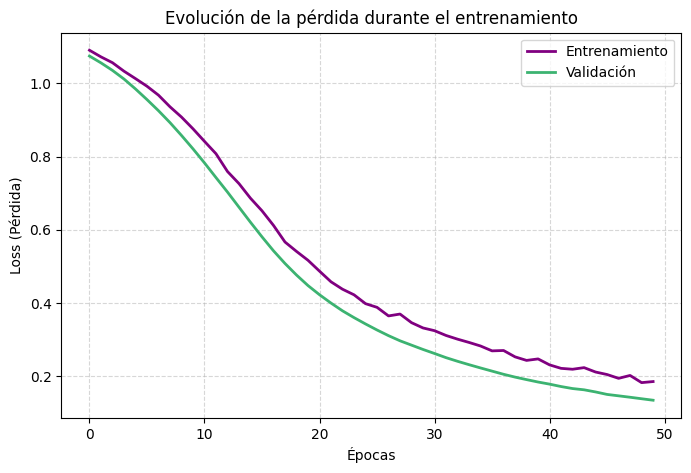

In [19]:
import matplotlib.pyplot as plt

# ==========================================
# 1. CREACIÓN Y CONFIGURACIÓN DE LA FIGURA
# ==========================================
# Define el lienzo donde se dibujará la gráfica (8x5 pulgadas).
plt.figure(figsize=(8, 5))


# ==========================================
# 2. GRAFICADO DE LAS CURVAS CON COLORES PERSONALIZADOS
# ==========================================
# Dibuja la curva de entrenamiento en color MORADO
plt.plot(train_losses, label="Entrenamiento", color="purple", linewidth=2)

# Dibuja la curva de validación en color VERDE
plt.plot(val_losses, label="Validación", color="mediumseagreen", linewidth=2)


# ==========================================
# 3. PERSONALIZACIÓN Y ETIQUETADO DEL GRÁFICO
# ==========================================
plt.xlabel("Épocas")
plt.ylabel("Loss (Pérdida)")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)  # Cuadrícula opcional para leer mejor los datos


# ==========================================
# 4. DESPLIEGUE DE LA FIGURA
# ==========================================
plt.show()